In [2]:
import glob

dosyalar = glob.glob("elektrik_tuketimi/*.csv")
print(dosyalar)
print("Dosya sayısı:", len(dosyalar))

['elektrik_tuketimi\\Gercek_Zamanli_Tuketim-04072015-04072016.csv', 'elektrik_tuketimi\\Gercek_Zamanli_Tuketim-04072016-04072017.csv', 'elektrik_tuketimi\\Gercek_Zamanli_Tuketim-04072017-04072018.csv', 'elektrik_tuketimi\\Gercek_Zamanli_Tuketim-04072018-04072019.csv', 'elektrik_tuketimi\\Gercek_Zamanli_Tuketim-04072019-04072020.csv', 'elektrik_tuketimi\\Gercek_Zamanli_Tuketim-04072020-04072021.csv', 'elektrik_tuketimi\\Gercek_Zamanli_Tuketim-04072021-04072022.csv', 'elektrik_tuketimi\\Gercek_Zamanli_Tuketim-04072022-04072023.csv', 'elektrik_tuketimi\\Gercek_Zamanli_Tuketim-04072023-04072024.csv', 'elektrik_tuketimi\\Gercek_Zamanli_Tuketim-04072024-04072025.csv', 'elektrik_tuketimi\\Gercek_Zamanli_Tuketim-04072025-04072026.csv']
Dosya sayısı: 11


In [3]:
import pandas as pd

df_test = pd.read_csv(
    dosyalar[0],
    sep=";",
    encoding="utf-8-sig",
    thousands=".",
    decimal=",",
    dtype={"Tarih": str, "Saat": str}
)

print(df_test.head())
print()
print(df_test.dtypes)

        Tarih   Saat  Tüketim Miktarı(MWh)
0  31.12.2015  00:00              29590.88
1  31.12.2015  01:00              27785.43
2  31.12.2015  02:00              26516.53
3  31.12.2015  03:00              26091.62
4  31.12.2015  04:00              25871.54

Tarih                    object
Saat                     object
Tüketim Miktarı(MWh)    float64
dtype: object


In [4]:
df_listesi = []

for dosya in dosyalar:
    df = pd.read_csv(
        dosya,
        sep=";",
        encoding="utf-8-sig",
        thousands=".",
        decimal=",",
        dtype={"Tarih": str, "Saat": str}
    )
    df_listesi.append(df)

print("Okunan dosya sayısı:", len(df_listesi))

Okunan dosya sayısı: 11


In [5]:
df = pd.concat(df_listesi, ignore_index=True)

print("Toplam satır sayısı:", len(df))
print()
print(df.head())
print(df.tail())

Toplam satır sayısı: 92366

        Tarih   Saat  Tüketim Miktarı(MWh)
0  31.12.2015  00:00              29590.88
1  31.12.2015  01:00              27785.43
2  31.12.2015  02:00              26516.53
3  31.12.2015  03:00              26091.62
4  31.12.2015  04:00              25871.54
            Tarih   Saat  Tüketim Miktarı(MWh)
92361  04.07.2026  09:00              45343.93
92362  04.07.2026  10:00              47101.32
92363  04.07.2026  11:00              47176.12
92364  04.07.2026  12:00              46742.32
92365  04.07.2026  13:00              45838.95


In [6]:
df["datetime"] = pd.to_datetime(
    df["Tarih"] + " " + df["Saat"],
    format="%d.%m.%Y %H:%M"
)

print(df[["Tarih", "Saat", "datetime"]].head())
print()
print("datetime tipi:", df["datetime"].dtype)

        Tarih   Saat            datetime
0  31.12.2015  00:00 2015-12-31 00:00:00
1  31.12.2015  01:00 2015-12-31 01:00:00
2  31.12.2015  02:00 2015-12-31 02:00:00
3  31.12.2015  03:00 2015-12-31 03:00:00
4  31.12.2015  04:00 2015-12-31 04:00:00

datetime tipi: datetime64[ns]


In [7]:
df = df.set_index("datetime").sort_index()

# Artık ham Tarih ve Saat sütunlarına gerek yok, sadece tüketim kalsın
df = df[["Tüketim Miktarı(MWh)"]]

# Sütun ismini sadeleştirelim, sonraki kodlarda yazması kolay olsun
df.columns = ["tuketim_mwh"]

print(df.head())
print("...")
print(df.tail())

                     tuketim_mwh
datetime                        
2015-12-31 00:00:00     29590.88
2015-12-31 01:00:00     27785.43
2015-12-31 02:00:00     26516.53
2015-12-31 03:00:00     26091.62
2015-12-31 04:00:00     25871.54
...
                     tuketim_mwh
datetime                        
2026-07-04 09:00:00     45343.93
2026-07-04 10:00:00     47101.32
2026-07-04 11:00:00     47176.12
2026-07-04 12:00:00     46742.32
2026-07-04 13:00:00     45838.95


In [8]:
# Tekrar eden (aynı) datetime kaç tane var?
cakisan_sayisi = df.index.duplicated().sum()
print("Çakışan (tekrar eden) saat sayısı:", cakisan_sayisi)

Çakışan (tekrar eden) saat sayısı: 241


In [9]:
# Çakışan tüm satırları göster (hem ilk hali hem tekrarı)
cakisanlar = df[df.index.duplicated(keep=False)]
print("Çakışan satır sayısı (ikisi de dahil):", len(cakisanlar))
print()
print(cakisanlar.head(20))

Çakışan satır sayısı (ikisi de dahil): 482

                     tuketim_mwh
datetime                        
2016-03-27 03:00:00     24776.94
2016-03-27 03:00:00     24776.94
2016-07-04 00:00:00     29803.41
2016-07-04 00:00:00     29803.41
2016-07-04 01:00:00     28820.36
2016-07-04 01:00:00     28820.36
2016-07-04 02:00:00     27622.82
2016-07-04 02:00:00     27622.82
2016-07-04 03:00:00     26381.32
2016-07-04 03:00:00     26381.32
2016-07-04 04:00:00     24435.77
2016-07-04 04:00:00     24435.77
2016-07-04 05:00:00     22441.18
2016-07-04 05:00:00     22441.18
2016-07-04 06:00:00     21631.00
2016-07-04 06:00:00     21631.00
2016-07-04 07:00:00     22622.35
2016-07-04 07:00:00     22622.35
2016-07-04 08:00:00     24346.79
2016-07-04 08:00:00     24346.79


In [10]:
# Silmeden önceki satır sayısını not edelim
onceki = len(df)

# Her tekrar eden tarihten sadece ilkini tut
df = df[~df.index.duplicated(keep="first")]

print("Önceki satır sayısı :", onceki)
print("Sonraki satır sayısı:", len(df))
print("Silinen tekrar       :", onceki - len(df))

Önceki satır sayısı : 92366
Sonraki satır sayısı: 92125
Silinen tekrar       : 241


In [11]:
# Verinin başından sonuna kadar olması gereken TAM saatlik takvim
tam_takvim = pd.date_range(start=df.index.min(), end=df.index.max(), freq="h")

print("Olması gereken saat sayısı:", len(tam_takvim))
print("Elimizdeki saat sayısı    :", len(df))
print("Eksik saat sayısı         :", len(tam_takvim) - len(df))

Olması gereken saat sayısı: 92126
Elimizdeki saat sayısı    : 92125
Eksik saat sayısı         : 1


In [12]:
# Tam takvimde olup bizim veride olmayan saati bul
eksik_saat = tam_takvim.difference(df.index)
print("Eksik olan saat:", eksik_saat)

Eksik olan saat: DatetimeIndex(['2016-03-27 04:00:00'], dtype='datetime64[ns]', freq='h')


In [13]:
# Silmeden önceki durumu not et
onceki = len(df)

# Veriyi kesintisiz tam takvime oturt (eksik saat NaN olarak belirir)
df = df.reindex(tam_takvim)

# Oluşan boşluğu komşu saatlerin değerleriyle doldur (zaman bazlı interpolasyon)
df["tuketim_mwh"] = df["tuketim_mwh"].interpolate(method="time")

# Index'e isim verelim (reindex sonrası kaybolmuş olabilir)
df.index.name = "datetime"

print("Önceki satır sayısı:", onceki)
print("Sonraki satır sayısı:", len(df))
print("Kalan eksik değer:", df["tuketim_mwh"].isnull().sum())
print()
# Doldurduğumuz saatin çevresine bakalım - mantıklı bir değer mi geldi?
print(df.loc["2016-03-27 02:00":"2016-03-27 06:00"])

Önceki satır sayısı: 92125
Sonraki satır sayısı: 92126
Kalan eksik değer: 0

                     tuketim_mwh
datetime                        
2016-03-27 02:00:00        0.000
2016-03-27 03:00:00    24776.940
2016-03-27 04:00:00    24437.955
2016-03-27 05:00:00    24098.970
2016-03-27 06:00:00    23267.430


In [14]:
# Kaç tane sıfır değer var?
sifir_sayisi = (df["tuketim_mwh"] == 0).sum()
print("Sıfır (0) değer sayısı:", sifir_sayisi)
print()

# Sıfır olan satırları göster
print("=== SIFIR OLAN SAATLER ===")
print(df[df["tuketim_mwh"] == 0])
print()

# Genel olarak en düşük 10 değere bakalım (anormal düşükler var mı?)
print("=== EN DÜŞÜK 10 DEĞER ===")
print(df["tuketim_mwh"].nsmallest(10))

Sıfır (0) değer sayısı: 1

=== SIFIR OLAN SAATLER ===
                     tuketim_mwh
datetime                        
2016-03-27 02:00:00          0.0

=== EN DÜŞÜK 10 DEĞER ===
datetime
2016-03-27 02:00:00        0.00
2020-05-25 07:00:00    15333.30
2020-05-25 08:00:00    15489.26
2020-05-25 06:00:00    15595.52
2020-05-25 09:00:00    15814.02
2020-05-26 07:00:00    16136.13
2020-05-26 06:00:00    16305.83
2020-05-26 08:00:00    16364.92
2020-05-25 05:00:00    16389.07
2020-05-25 10:00:00    16507.11
Name: tuketim_mwh, dtype: float64


In [15]:
# 0'ı önce "eksik" (NaN) yap, sonra komşularından doldur
import numpy as np

df["tuketim_mwh"] = df["tuketim_mwh"].replace(0, np.nan)
df["tuketim_mwh"] = df["tuketim_mwh"].interpolate(method="time")

# Kontrol: artık 0 var mı, NaN var mı?
print("Sıfır değer sayısı:", (df["tuketim_mwh"] == 0).sum())
print("Eksik (NaN) değer :", df["tuketim_mwh"].isnull().sum())
print()
# Düzelttiğimiz saatin çevresine tekrar bakalım
print(df.loc["2016-03-27 00:00":"2016-03-27 06:00"])

Sıfır değer sayısı: 0
Eksik (NaN) değer : 0

                     tuketim_mwh
datetime                        
2016-03-27 00:00:00    27424.420
2016-03-27 01:00:00    25949.630
2016-03-27 02:00:00    25363.285
2016-03-27 03:00:00    24776.940
2016-03-27 04:00:00    24437.955
2016-03-27 05:00:00    24098.970
2016-03-27 06:00:00    23267.430


In [16]:
# Temiz veriyi tek bir CSV olarak kaydet
df.to_csv("elektrik_tuketimi_temiz.csv")

print("Kaydedildi.")
print("Satır sayısı:", len(df))
print("Tarih aralığı:", df.index.min(), "->", df.index.max())

Kaydedildi.
Satır sayısı: 92126
Tarih aralığı: 2015-12-31 00:00:00 -> 2026-07-04 13:00:00


In [17]:
# Kaydettiğimiz temiz dosyayı geri oku
kontrol = pd.read_csv(
    "elektrik_tuketimi_temiz.csv",
    index_col="datetime",
    parse_dates=True
)

print(kontrol.head())
print()
print("Satır sayısı:", len(kontrol))
print("Index tipi:", kontrol.index.dtype)
print("Eksik değer:", kontrol.isnull().sum().sum())

                     tuketim_mwh
datetime                        
2015-12-31 00:00:00     29590.88
2015-12-31 01:00:00     27785.43
2015-12-31 02:00:00     26516.53
2015-12-31 03:00:00     26091.62
2015-12-31 04:00:00     25871.54

Satır sayısı: 92126
Index tipi: datetime64[ns]
Eksik değer: 0


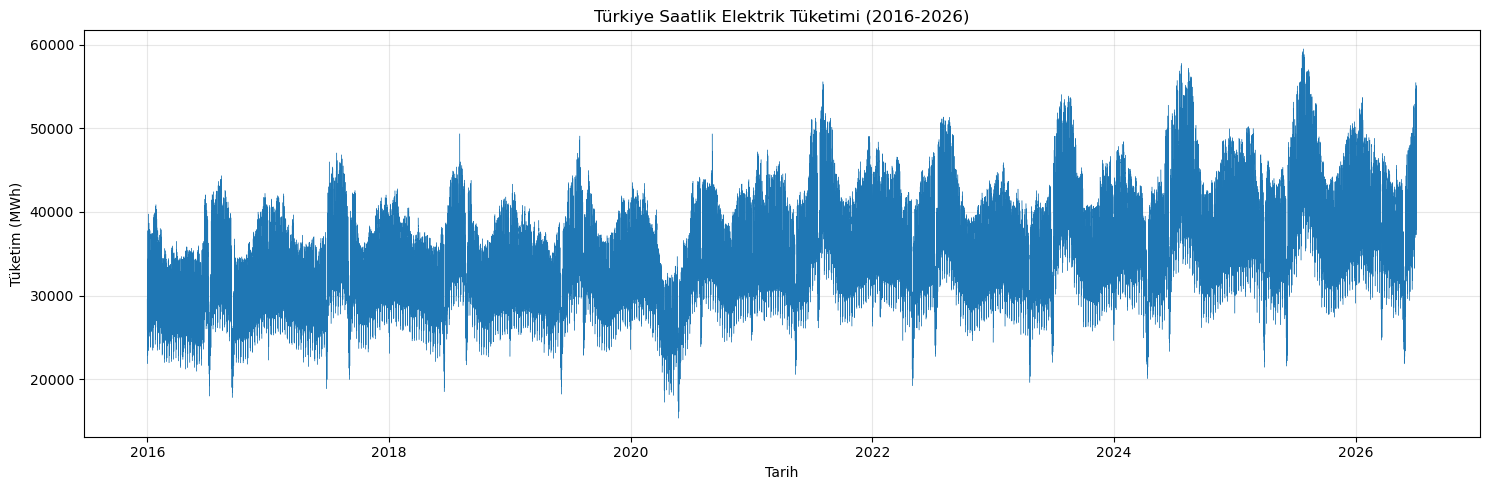

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(df.index, df["tuketim_mwh"], linewidth=0.3)
plt.title("Türkiye Saatlik Elektrik Tüketimi (2016-2026)")
plt.xlabel("Tarih")
plt.ylabel("Tüketim (MWh)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Genel Görünüm

Türkiye'nin 2015-2026 saatlik elektrik tüketimi. Üç ana örüntü görülüyor:

- **Yükseliş trendi:** Tüketim yıllar içinde ~30.000 MWh'den ~40.000+ MWh'ye çıkmış.
- **Yıllık mevsimsellik:** Her yıl yaz ve kış aylarında tepe, geçiş mevsimlerinde düşüş.
- **2020 anomalisi:** Covid döneminde belirgin bir düşüş var.

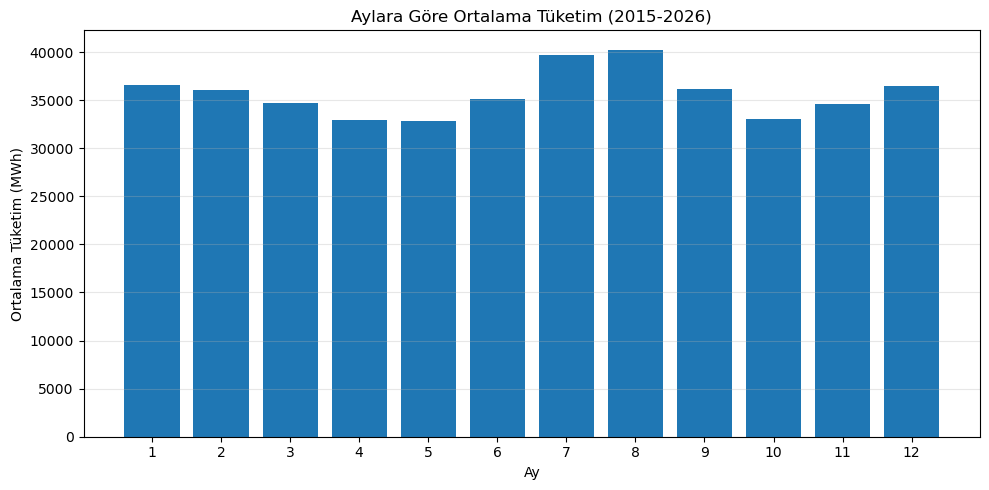

In [19]:
# Her satırın hangi aya ait olduğunu bul, sonra aylara göre ortalama al
aylik_ortalama = df.groupby(df.index.month)["tuketim_mwh"].mean()

plt.figure(figsize=(10, 5))
plt.bar(aylik_ortalama.index, aylik_ortalama.values)
plt.title("Aylara Göre Ortalama Tüketim (2015-2026)")
plt.xlabel("Ay")
plt.ylabel("Ortalama Tüketim (MWh)")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

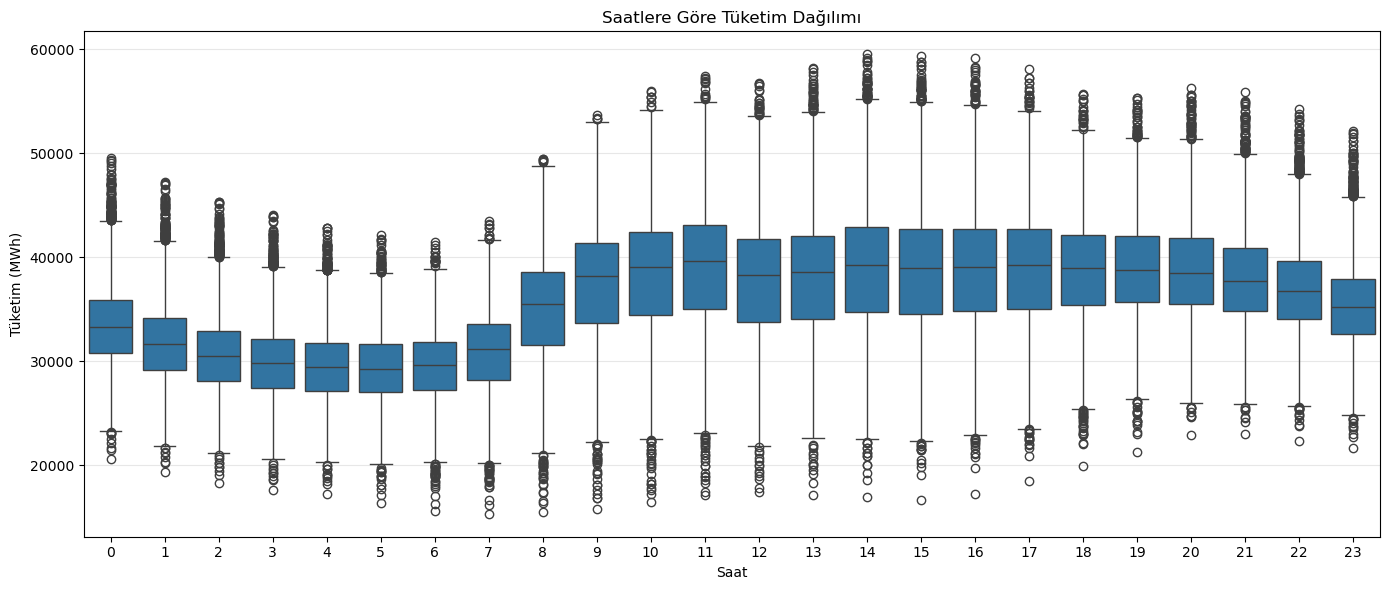

In [20]:
!pip install seaborn
import seaborn as sns

# Saat sütununu ekleyelim (henüz yoksa)
df["saat"] = df.index.hour

plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x="saat", y="tuketim_mwh")
plt.title("Saatlere Göre Tüketim Dağılımı")
plt.xlabel("Saat")
plt.ylabel("Tüketim (MWh)")
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

 ## Bu iki grafikten anladığımız tüketim hem saate hem aya çok güçlü bağlı

Ağustos zirve, geçiş ayları dip; günlük döngüde gece dip, gündüz plato. Gündüz saatlerinin yüksek varyansı sıcaklık etkisine işaret ediyor.

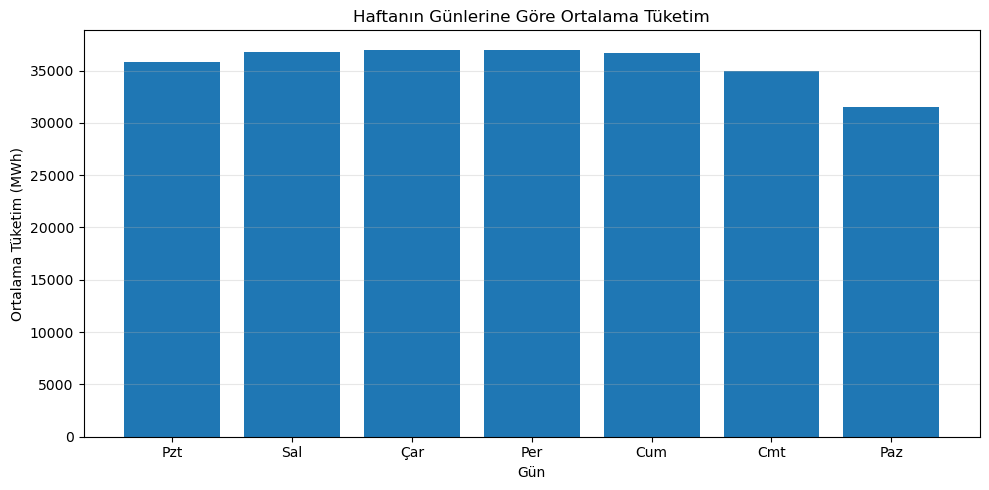

In [22]:
# Haftanın günü bilgisini çıkar (0=Pazartesi ... 6=Pazar)
df["haftanin_gunu"] = df.index.dayofweek

# Güne göre ortalama tüketim
gunluk_ortalama = df.groupby("haftanin_gunu")["tuketim_mwh"].mean()

# Gün isimlerini ekleyelim ki grafik okunaklı olsun
gun_isimleri = ["Pzt", "Sal", "Çar", "Per", "Cum", "Cmt", "Paz"]

plt.figure(figsize=(10, 5))
plt.bar(gun_isimleri, gunluk_ortalama.values)
plt.title("Haftanın Günlerine Göre Ortalama Tüketim")
plt.xlabel("Gün")
plt.ylabel("Ortalama Tüketim (MWh)")
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

In [23]:
# Bilinen birkaç tarihi kontrol edelim
test_tarihleri = ["2015-12-31", "2020-01-01", "2024-04-23"]

for tarih in test_tarihleri:
    gun_no = pd.Timestamp(tarih).dayofweek
    gunler = ["Pazartesi", "Salı", "Çarşamba", "Perşembe", "Cuma", "Cumartesi", "Pazar"]
    print(f"{tarih} -> {gunler[gun_no]}")

2015-12-31 -> Perşembe
2020-01-01 -> Çarşamba
2024-04-23 -> Salı


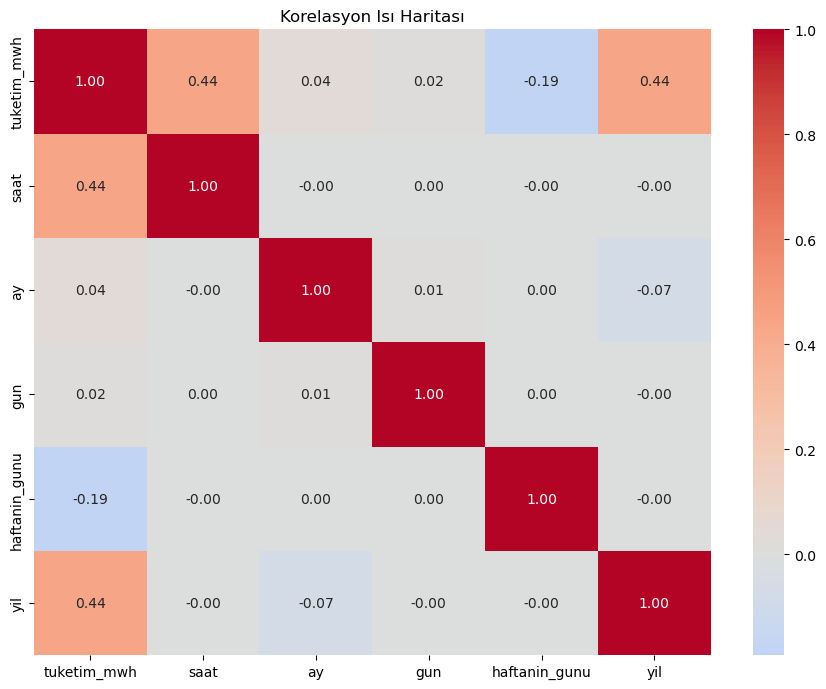

In [26]:
# Korelasyon için sayısal zaman sütunları üretelim
df["saat"] = df.index.hour
df["ay"] = df.index.month
df["gun"] = df.index.day
df["haftanin_gunu"] = df.index.dayofweek
df["yil"] = df.index.year

# Bu sütunların tüketimle ve birbirleriyle korelasyonunu hesapla
korelasyon = df[["tuketim_mwh", "saat", "ay", "gun", "haftanin_gunu", "yil"]].corr()

# Isı haritası olarak çiz
plt.figure(figsize=(9, 7))
sns.heatmap(korelasyon, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Korelasyon Isı Haritası")
plt.tight_layout()
plt.show()

Korelasyon yalnızca doğrusal ilişkileri ölçer; ay (0.04) ve saat gibi döngüsel değişkenlerin etkisi bu yüzden düşük görünüyor. Bu değişkenler için sin/cos kodlaması gerekiyor. Yıl (0.44) ve haftanın günü (-0.19) doğrusal etkileri net yansıtıyor.

In [27]:
print("Sütunlar:", df.columns.tolist())
print("Index tipi:", type(df.index).__name__)
print("Index sıralı mı?:", df.index.is_monotonic_increasing)
print("Satır sayısı:", len(df))

Sütunlar: ['tuketim_mwh', 'saat', 'haftanin_gunu', 'ay', 'gun', 'yil']
Index tipi: DatetimeIndex
Index sıralı mı?: True
Satır sayısı: 92126


In [28]:
# lag_24: 24 saat önceki (dün aynı saatteki) tüketim
df["lag_24"] = df["tuketim_mwh"].shift(24)

# Doğru çalıştı mı, gözle kontrol edelim
print(df[["tuketim_mwh", "lag_24"]].head(30))

                     tuketim_mwh    lag_24
datetime                                  
2015-12-31 00:00:00     29590.88       NaN
2015-12-31 01:00:00     27785.43       NaN
2015-12-31 02:00:00     26516.53       NaN
2015-12-31 03:00:00     26091.62       NaN
2015-12-31 04:00:00     25871.54       NaN
2015-12-31 05:00:00     26053.84       NaN
2015-12-31 06:00:00     26889.99       NaN
2015-12-31 07:00:00     28103.02       NaN
2015-12-31 08:00:00     32321.87       NaN
2015-12-31 09:00:00     35759.14       NaN
2015-12-31 10:00:00     37296.87       NaN
2015-12-31 11:00:00     37768.72       NaN
2015-12-31 12:00:00     36450.06       NaN
2015-12-31 13:00:00     36764.22       NaN
2015-12-31 14:00:00     36830.18       NaN
2015-12-31 15:00:00     36026.14       NaN
2015-12-31 16:00:00     36069.28       NaN
2015-12-31 17:00:00     35753.29       NaN
2015-12-31 18:00:00     33700.44       NaN
2015-12-31 19:00:00     32030.51       NaN
2015-12-31 20:00:00     30138.36       NaN
2015-12-31 

In [29]:
# lag_168: 168 saat (tam 1 hafta) önceki tüketim
df["lag_168"] = df["tuketim_mwh"].shift(168)

# Kontrol: ilk 168 satır NaN olmalı, 169. satırdan itibaren dolmalı
print("İlk 168 satırdaki NaN sayısı:", df["lag_168"].head(168).isnull().sum())
print()
# 169. satırın lag_168'i, 1. satırın tüketimine eşit mi?
print("169. satırın lag_168 değeri:", df["lag_168"].iloc[168])
print("1. satırın tuketim değeri  :", df["tuketim_mwh"].iloc[0])

İlk 168 satırdaki NaN sayısı: 168

169. satırın lag_168 değeri: 29590.88
1. satırın tuketim değeri  : 29590.88


In [30]:
print("lag_24 dolu satır sayısı :", df["lag_24"].notnull().sum())
print("lag_168 dolu satır sayısı:", df["lag_168"].notnull().sum())
print()
# Ortalarda bir yere bakalım - mesela 2020 yılından bir kesit
print(df.loc["2020-06-15 12:00":"2020-06-15 17:00", ["tuketim_mwh", "lag_24", "lag_168"]])

lag_24 dolu satır sayısı : 92102
lag_168 dolu satır sayısı: 91958

                     tuketim_mwh    lag_24   lag_168
datetime                                            
2020-06-15 12:00:00     33179.66  25926.11  32774.56
2020-06-15 13:00:00     34536.20  26445.29  33777.62
2020-06-15 14:00:00     35379.39  26800.55  35008.33
2020-06-15 15:00:00     35486.25  26931.23  35042.56
2020-06-15 16:00:00     35891.20  27172.95  35262.48
2020-06-15 17:00:00     35803.20  27598.40  35196.31


In [32]:
# rolling_mean_24: son 24 saatin ortalaması AMA şu anki saati dahil etmeden
# shift(1) = önce bir saat geriye kaydır (şu anki değeri dışarıda bırak)
# .rolling(24).mean() = sonra 24 saatlik pencerenin ortalamasını al
df["rolling_mean_24"] = df["tuketim_mwh"].shift(1).rolling(window=24).mean()

# Kontrol edelim
print(df[["tuketim_mwh", "rolling_mean_24"]].head(30))

                     tuketim_mwh  rolling_mean_24
datetime                                         
2015-12-31 00:00:00     29590.88              NaN
2015-12-31 01:00:00     27785.43              NaN
2015-12-31 02:00:00     26516.53              NaN
2015-12-31 03:00:00     26091.62              NaN
2015-12-31 04:00:00     25871.54              NaN
2015-12-31 05:00:00     26053.84              NaN
2015-12-31 06:00:00     26889.99              NaN
2015-12-31 07:00:00     28103.02              NaN
2015-12-31 08:00:00     32321.87              NaN
2015-12-31 09:00:00     35759.14              NaN
2015-12-31 10:00:00     37296.87              NaN
2015-12-31 11:00:00     37768.72              NaN
2015-12-31 12:00:00     36450.06              NaN
2015-12-31 13:00:00     36764.22              NaN
2015-12-31 14:00:00     36830.18              NaN
2015-12-31 15:00:00     36026.14              NaN
2015-12-31 16:00:00     36069.28              NaN
2015-12-31 17:00:00     35753.29              NaN


In [33]:
# rolling_std_24: son 24 saatin standart sapması (oynaklık), yine şu anki saat hariç
df["rolling_std_24"] = df["tuketim_mwh"].shift(1).rolling(window=24).std()

# Kontrol
print(df[["tuketim_mwh", "rolling_mean_24", "rolling_std_24"]].loc["2016-01-01 00:00":"2016-01-01 06:00"])

                     tuketim_mwh  rolling_mean_24  rolling_std_24
datetime                                                         
2016-01-01 00:00:00     26277.24     31628.513750     4340.195753
2016-01-01 01:00:00     24991.82     31490.445417     4458.916576
2016-01-01 02:00:00     23532.61     31374.045000     4594.251452
2016-01-01 03:00:00     22464.78     31249.715000     4768.492732
2016-01-01 04:00:00     22002.91     31098.596667     4991.327629
2016-01-01 05:00:00     21957.08     30937.403750     5224.494497
2016-01-01 06:00:00     22203.54     30766.705417     5452.923400


In [34]:
# Saati daire üzerine yerleştir: sin ve cos ile iki bileşen
df["saat_sin"] = np.sin(2 * np.pi * df["saat"] / 24)
df["saat_cos"] = np.cos(2 * np.pi * df["saat"] / 24)

# Kontrol: birkaç saati görelim
print(df[["saat", "saat_sin", "saat_cos"]].drop_duplicates().sort_values("saat").head(24))

                     saat      saat_sin      saat_cos
datetime                                             
2015-12-31 00:00:00     0  0.000000e+00  1.000000e+00
2015-12-31 01:00:00     1  2.588190e-01  9.659258e-01
2015-12-31 02:00:00     2  5.000000e-01  8.660254e-01
2015-12-31 03:00:00     3  7.071068e-01  7.071068e-01
2015-12-31 04:00:00     4  8.660254e-01  5.000000e-01
2015-12-31 05:00:00     5  9.659258e-01  2.588190e-01
2015-12-31 06:00:00     6  1.000000e+00  6.123234e-17
2015-12-31 07:00:00     7  9.659258e-01 -2.588190e-01
2015-12-31 08:00:00     8  8.660254e-01 -5.000000e-01
2015-12-31 09:00:00     9  7.071068e-01 -7.071068e-01
2015-12-31 10:00:00    10  5.000000e-01 -8.660254e-01
2015-12-31 11:00:00    11  2.588190e-01 -9.659258e-01
2015-12-31 12:00:00    12  1.224647e-16 -1.000000e+00
2015-12-31 13:00:00    13 -2.588190e-01 -9.659258e-01
2015-12-31 14:00:00    14 -5.000000e-01 -8.660254e-01
2015-12-31 15:00:00    15 -7.071068e-01 -7.071068e-01
2015-12-31 16:00:00    16 -8

In [35]:
# Ay için döngüsel kodlama (12 ay bir daire)
df["ay_sin"] = np.sin(2 * np.pi * df["ay"] / 12)
df["ay_cos"] = np.cos(2 * np.pi * df["ay"] / 12)

# Kontrol: 12 ayı görelim, özellikle Aralık(12) ile Ocak(1) komşu mu?
print(df[["ay", "ay_sin", "ay_cos"]].drop_duplicates().sort_values("ay"))

            ay        ay_sin        ay_cos
datetime                                  
2016-01-01   1  5.000000e-01  8.660254e-01
2016-02-01   2  8.660254e-01  5.000000e-01
2016-03-01   3  1.000000e+00  6.123234e-17
2016-04-01   4  8.660254e-01 -5.000000e-01
2016-05-01   5  5.000000e-01 -8.660254e-01
2016-06-01   6  1.224647e-16 -1.000000e+00
2016-07-01   7 -5.000000e-01 -8.660254e-01
2016-08-01   8 -8.660254e-01 -5.000000e-01
2016-09-01   9 -1.000000e+00 -1.836970e-16
2016-10-01  10 -8.660254e-01  5.000000e-01
2016-11-01  11 -5.000000e-01  8.660254e-01
2015-12-31  12 -2.449294e-16  1.000000e+00


In [36]:
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# Tekrar bakalım, şimdi normal ondalıkla
print(df[["ay", "ay_sin", "ay_cos"]].drop_duplicates().sort_values("ay"))

            ay  ay_sin  ay_cos
datetime                      
2016-01-01   1  0.5000  0.8660
2016-02-01   2  0.8660  0.5000
2016-03-01   3  1.0000  0.0000
2016-04-01   4  0.8660 -0.5000
2016-05-01   5  0.5000 -0.8660
2016-06-01   6  0.0000 -1.0000
2016-07-01   7 -0.5000 -0.8660
2016-08-01   8 -0.8660 -0.5000
2016-09-01   9 -1.0000 -0.0000
2016-10-01  10 -0.8660  0.5000
2016-11-01  11 -0.5000  0.8660
2015-12-31  12 -0.0000  1.0000


In [37]:
# Tüm sütunları ve kaç tanesi dolu görelim
print("=== TÜM SÜTUNLAR ===")
print(df.columns.tolist())
print()
print("Toplam sütun sayısı:", len(df.columns))
print("Toplam satır sayısı:", len(df))
print()
print("=== HER SÜTUNDA KAÇ EKSİK (NaN) VAR ===")
print(df.isnull().sum())

=== TÜM SÜTUNLAR ===
['tuketim_mwh', 'saat', 'haftanin_gunu', 'ay', 'gun', 'yil', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_std_24', 'saat_sin', 'saat_cos', 'ay_sin', 'ay_cos']

Toplam sütun sayısı: 14
Toplam satır sayısı: 92126

=== HER SÜTUNDA KAÇ EKSİK (NaN) VAR ===
tuketim_mwh          0
saat                 0
haftanin_gunu        0
ay                   0
gun                  0
yil                  0
lag_24              24
lag_168            168
rolling_mean_24     24
rolling_std_24      24
saat_sin             0
saat_cos             0
ay_sin               0
ay_cos               0
dtype: int64


In [38]:
# NaN içeren satırları (ilk 168 satır) at
onceki = len(df)
df_model = df.dropna()

print("Önceki satır sayısı:", onceki)
print("Sonraki satır sayısı:", len(df_model))
print("Atılan satır:", onceki - len(df_model))
print("Kalan NaN:", df_model.isnull().sum().sum())

Önceki satır sayısı: 92126
Sonraki satır sayısı: 91958
Atılan satır: 168
Kalan NaN: 0


In [39]:
# Bölme tarihi: son 1 yılı test için ayır
bolme_tarihi = "2025-07-04"

# Bu tarihten ÖNCESİ eğitim, SONRASI test
train = df_model.loc[df_model.index < bolme_tarihi]
test = df_model.loc[df_model.index >= bolme_tarihi]

print("Eğitim (train) seti:")
print("  Satır sayısı:", len(train))
print("  Tarih aralığı:", train.index.min(), "->", train.index.max())
print()
print("Test seti:")
print("  Satır sayısı:", len(test))
print("  Tarih aralığı:", test.index.min(), "->", test.index.max())
print()
print("Test oranı:", f"{len(test) / len(df_model) * 100:.1f}%")

Eğitim (train) seti:
  Satır sayısı: 83184
  Tarih aralığı: 2016-01-07 00:00:00 -> 2025-07-03 23:00:00

Test seti:
  Satır sayısı: 8774
  Tarih aralığı: 2025-07-04 00:00:00 -> 2026-07-04 13:00:00

Test oranı: 9.5%


In [40]:
# Hedef sütunu
hedef = "tuketim_mwh"

# Özellik sütunları: tuketim_mwh HARİÇ her şey
ozellikler = [sutun for sutun in df_model.columns if sutun != hedef]

print("Hedef (y):", hedef)
print()
print("Özellikler (X):", ozellikler)
print("Özellik sayısı:", len(ozellikler))

# Train ve test'i X ve y olarak ayır
X_train = train[ozellikler]
y_train = train[hedef]

X_test = test[ozellikler]
y_test = test[hedef]

print()
print("X_train boyutu:", X_train.shape)
print("y_train boyutu:", y_train.shape)
print("X_test boyutu:", X_test.shape)
print("y_test boyutu:", y_test.shape)

Hedef (y): tuketim_mwh

Özellikler (X): ['saat', 'haftanin_gunu', 'ay', 'gun', 'yil', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_std_24', 'saat_sin', 'saat_cos', 'ay_sin', 'ay_cos']
Özellik sayısı: 13

X_train boyutu: (83184, 13)
y_train boyutu: (83184,)
X_test boyutu: (8774, 13)
y_test boyutu: (8774,)


In [41]:
!pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)


In [42]:
import lightgbm as lgb

# Modeli oluştur
model = lgb.LGBMRegressor(
    n_estimators=500,      # kaç ağaç kurulacak
    learning_rate=0.05,    # her ağacın öğrenme hızı
    random_state=42        # sonuçların tekrarlanabilir olması için
)

# Modeli EĞİTİM verisiyle eğit
model.fit(X_train, y_train)

print("Model eğitildi!")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001139 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1167
[LightGBM] [Info] Number of data points in the train set: 83184, number of used features: 13
[LightGBM] [Info] Start training from score 35145.795585
Model eğitildi!


In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Model TEST setinde tahmin yapsın (ilk kez test verisine dokunuyoruz)
y_pred = model.predict(X_test)

# Ne kadar isabetli? Üç metrikle ölçelim
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = r2_score(y_test, y_pred)

print("=== MODEL PERFORMANSI (test seti - son 1 yıl) ===")
print(f"MAE  (ortalama mutlak hata): {mae:,.0f} MWh")
print(f"RMSE (kök ortalama kare hata): {rmse:,.0f} MWh")
print(f"MAPE (ortalama yüzde hata): {mape:.2f}%")
print(f"R²   (açıklanan varyans): {r2:.4f}")

=== MODEL PERFORMANSI (test seti - son 1 yıl) ===
MAE  (ortalama mutlak hata): 752 MWh
RMSE (kök ortalama kare hata): 1,131 MWh
MAPE (ortalama yüzde hata): 1.86%
R²   (açıklanan varyans): 0.9704


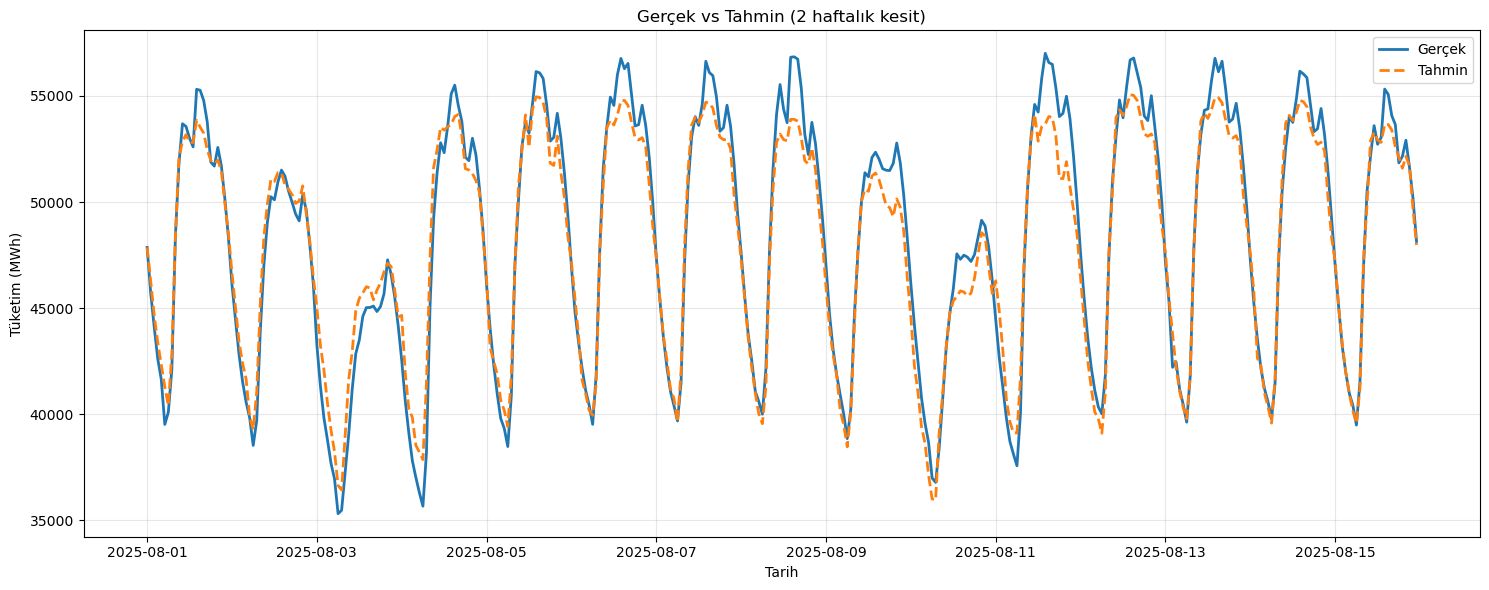

In [44]:
import matplotlib.pyplot as plt

# Tahminleri bir seri haline getir (test'in tarihleriyle eşleştir)
tahmin_serisi = pd.Series(y_pred, index=y_test.index)

# Test setinden 2 haftalık bir kesit seçelim (yakından bakmak için)
baslangic = "2025-08-01"
bitis = "2025-08-15"

plt.figure(figsize=(15, 6))
plt.plot(y_test.loc[baslangic:bitis].index, y_test.loc[baslangic:bitis].values, 
         label="Gerçek", linewidth=2)
plt.plot(tahmin_serisi.loc[baslangic:bitis].index, tahmin_serisi.loc[baslangic:bitis].values, 
         label="Tahmin", linewidth=2, linestyle="--")
plt.title("Gerçek vs Tahmin (2 haftalık kesit)")
plt.xlabel("Tarih")
plt.ylabel("Tüketim (MWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

model genel anlamda iyi tahmin yapıyor ama tepe noktalarında az da olsa hata yapıyor  bunun nedeni havdurumuyla alakalı olabilir mesela çok sıcak havalarda kullanılan klima gibidüşünebiliriz bu da bize model eğitim konusunda bir fikir veriyor

In [45]:
!pip install requests

In [46]:
import requests

# Open-Meteo geçmiş hava arşivi - İstanbul için KISA bir test (sadece birkaç gün)
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 41.01,      # İstanbul
    "longitude": 28.98,
    "start_date": "2024-01-01",
    "end_date": "2024-01-05",   # sadece 5 gün, test için
    "hourly": "temperature_2m"  # saatlik 2 metre sıcaklık
}

response = requests.get(url, params=params)
data = response.json()

# Ne geldi görelim
print("Durum kodu:", response.status_code)
print()
print("Gelen anahtarlar:", list(data.keys()))
print()
# İlk birkaç saatlik sıcaklık
print("İlk 10 saatlik sıcaklık:", data["hourly"]["temperature_2m"][:10])
print("İlk 10 zaman damgası:", data["hourly"]["time"][:10])

Durum kodu: 200

Gelen anahtarlar: ['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly']

İlk 10 saatlik sıcaklık: [9.7, 8.6, 8.2, 8.5, 8.7, 8.5, 8.7, 10.6, 11.9, 12.9]
İlk 10 zaman damgası: ['2024-01-01T00:00', '2024-01-01T01:00', '2024-01-01T02:00', '2024-01-01T03:00', '2024-01-01T04:00', '2024-01-01T05:00', '2024-01-01T06:00', '2024-01-01T07:00', '2024-01-01T08:00', '2024-01-01T09:00']


In [47]:
import pandas as pd

# 3 büyük şehir ve koordinatları
sehirler = {
    "istanbul": (41.01, 28.98),
    "ankara":   (39.93, 32.87),
    "izmir":    (38.42, 27.14)
}

# Tüketim verimizle aynı aralık
baslangic = "2016-01-01"
bitis = "2026-07-04"

# Her şehrin sıcaklığını ayrı bir sözlükte toplayacağız
sicaklik_verileri = {}

for sehir, (lat, lon) in sehirler.items():
    print(f"{sehir} çekiliyor...")
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": baslangic,
        "end_date": bitis,
        "hourly": "temperature_2m"
    }
    response = requests.get(url, params=params)
    data = response.json()
    
    # Bu şehrin zaman ve sıcaklık verisini bir seriye çevir
    zaman = pd.to_datetime(data["hourly"]["time"])
    sicaklik = data["hourly"]["temperature_2m"]
    sicaklik_verileri[sehir] = pd.Series(sicaklik, index=zaman)
    print(f"  {sehir}: {len(sicaklik)} saatlik kayıt geldi")

print()
print("Tüm şehirler çekildi!")

istanbul çekiliyor...
  istanbul: 92112 saatlik kayıt geldi
ankara çekiliyor...
  ankara: 92112 saatlik kayıt geldi
izmir çekiliyor...
  izmir: 92112 saatlik kayıt geldi

Tüm şehirler çekildi!


In [48]:
# Üç şehrin serilerini tek bir DataFrame'de birleştir
sicaklik_df = pd.DataFrame(sicaklik_verileri)

# Üç şehrin ortalaması = Türkiye geneli sıcaklık
sicaklik_df["sicaklik_ort"] = sicaklik_df.mean(axis=1)

print(sicaklik_df.head())
print()
print("Boyut:", sicaklik_df.shape)
print("Eksik değer:", sicaklik_df.isnull().sum().sum())
print()
print("Ortalama sıcaklık istatistikleri:")
print(sicaklik_df["sicaklik_ort"].describe())

                     istanbul  ankara   izmir  sicaklik_ort
2016-01-01 00:00:00   -0.3000 -6.7000 -1.6000       -2.8667
2016-01-01 01:00:00   -0.1000 -6.8000 -1.6000       -2.8333
2016-01-01 02:00:00   -0.1000 -7.0000 -1.6000       -2.9000
2016-01-01 03:00:00    0.0000 -7.1000 -1.8000       -2.9667
2016-01-01 04:00:00    0.1000 -7.3000 -1.9000       -3.0333

Boyut: (92112, 4)
Eksik değer: 0

Ortalama sıcaklık istatistikleri:
count   92112.0000
mean       15.5996
std         8.4651
min        -8.0000
25%         8.8667
50%        15.0333
75%        22.1000
max        39.1333
Name: sicaklik_ort, dtype: float64


In [49]:
# Sadece ortalama sıcaklık sütununu alalım (şehir detaylarına gerek yok)
sicaklik_seri = sicaklik_df["sicaklik_ort"]

# df_model'e sıcaklığı ekle - tarih index'i üzerinden eşleştirerek
df_model = df_model.copy()  # güvenli olması için kopya
df_model["sicaklik"] = sicaklik_seri

# Birleştirme sonrası kontrol
print("Boyut:", df_model.shape)
print("Sıcaklıkta eksik (NaN) değer:", df_model["sicaklik"].isnull().sum())
print()
print(df_model[["tuketim_mwh", "sicaklik"]].head())
print()
print(df_model[["tuketim_mwh", "sicaklik"]].tail())

Boyut: (91958, 15)
Sıcaklıkta eksik (NaN) değer: 0

                     tuketim_mwh  sicaklik
datetime                                  
2016-01-07 00:00:00   28763.9500   11.3000
2016-01-07 01:00:00   27284.8400   11.4333
2016-01-07 02:00:00   26321.9500   11.5333
2016-01-07 03:00:00   25748.4900   11.5333
2016-01-07 04:00:00   25636.5800   11.2000

                     tuketim_mwh  sicaklik
datetime                                  
2026-07-04 09:00:00   45343.9300   28.8667
2026-07-04 10:00:00   47101.3200   29.6667
2026-07-04 11:00:00   47176.1200   29.1333
2026-07-04 12:00:00   46742.3200   29.0333
2026-07-04 13:00:00   45838.9500   29.2000


In [50]:
# Sıcaklık ile tüketim arasındaki korelasyon
kor = df_model["sicaklik"].corr(df_model["tuketim_mwh"])
print(f"Sıcaklık - Tüketim korelasyonu: {kor:.3f}")

Sıcaklık - Tüketim korelasyonu: 0.248


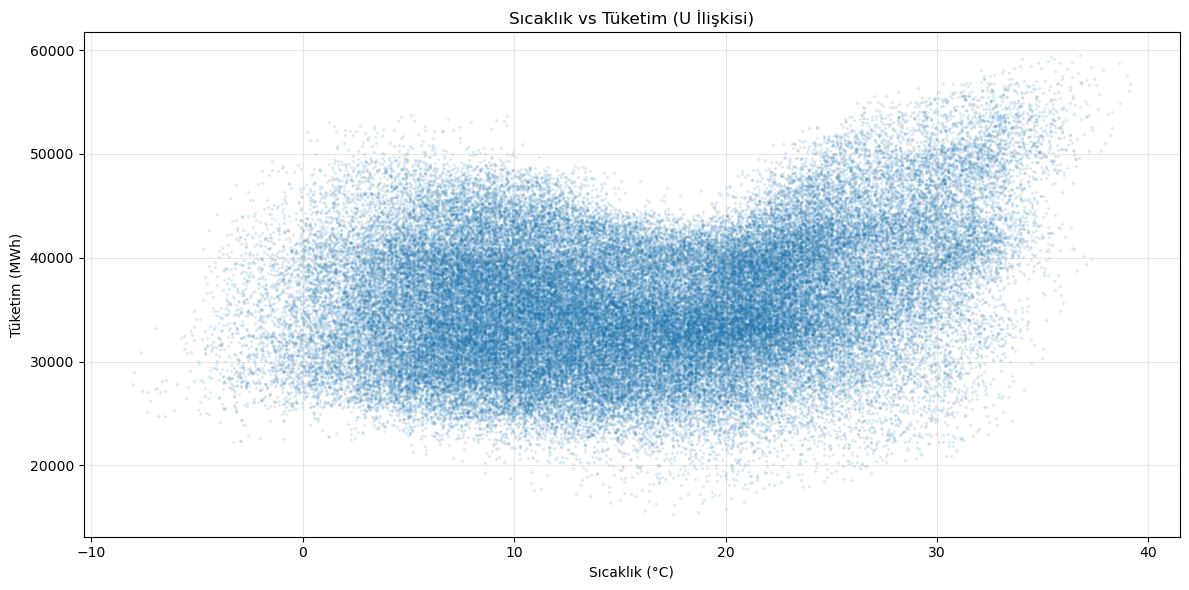

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.scatter(df_model["sicaklik"], df_model["tuketim_mwh"], 
            alpha=0.1, s=2)
plt.title("Sıcaklık vs Tüketim (U İlişkisi)")
plt.xlabel("Sıcaklık (°C)")
plt.ylabel("Tüketim (MWh)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

grafik U şeklinde buyüzden kolerasyon çok işe yaramadı yazın klima kullanımında elektrik tüketimi kışın ısıtıcı tüketiminden fazla anladığımız

In [52]:
# Sıcaklığı train ve test setlerine ekle
# df_model'de sıcaklık zaten var, onu train/test tarihlerine göre böleceğiz

# Özellik listesine sıcaklığı ekle
ozellikler_yeni = ozellikler + ["sicaklik"]

print("Yeni özellik listesi:", ozellikler_yeni)
print("Yeni özellik sayısı:", len(ozellikler_yeni))

# Train ve test'i yeni özelliklerle yeniden oluştur (aynı tarih bölmesi)
bolme_tarihi = "2025-07-04"

train_yeni = df_model.loc[df_model.index < bolme_tarihi]
test_yeni = df_model.loc[df_model.index >= bolme_tarihi]

X_train_yeni = train_yeni[ozellikler_yeni]
y_train_yeni = train_yeni[hedef]
X_test_yeni = test_yeni[ozellikler_yeni]
y_test_yeni = test_yeni[hedef]

print()
print("X_train_yeni boyutu:", X_train_yeni.shape)
print("X_test_yeni boyutu:", X_test_yeni.shape)

Yeni özellik listesi: ['saat', 'haftanin_gunu', 'ay', 'gun', 'yil', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_std_24', 'saat_sin', 'saat_cos', 'ay_sin', 'ay_cos', 'sicaklik']
Yeni özellik sayısı: 14

X_train_yeni boyutu: (83184, 14)
X_test_yeni boyutu: (8774, 14)


In [53]:
# Yeni modeli oluştur (eskiyle AYNI ayarlar - adil karşılaştırma için)
model_yeni = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)

# Sıcaklıklı veriyle eğit
model_yeni.fit(X_train_yeni, y_train_yeni)

# Test setinde tahmin
y_pred_yeni = model_yeni.predict(X_test_yeni)

# Metrikleri hesapla
mae_yeni = mean_absolute_error(y_test_yeni, y_pred_yeni)
rmse_yeni = np.sqrt(mean_squared_error(y_test_yeni, y_pred_yeni))
mape_yeni = np.mean(np.abs((y_test_yeni - y_pred_yeni) / y_test_yeni)) * 100
r2_yeni = r2_score(y_test_yeni, y_pred_yeni)

# KARŞILAŞTIRMA TABLOSU
print("=" * 55)
print(f"{'Metrik':<12}{'Sıcaklıksız':<18}{'Sıcaklıklı':<18}")
print("=" * 55)
print(f"{'MAE':<12}{mae:>10,.0f} MWh    {mae_yeni:>10,.0f} MWh")
print(f"{'RMSE':<12}{rmse:>10,.0f} MWh    {rmse_yeni:>10,.0f} MWh")
print(f"{'MAPE':<12}{mape:>10.2f}%      {mape_yeni:>10.2f}%")
print(f"{'R²':<12}{r2:>10.4f}       {r2_yeni:>10.4f}")
print("=" * 55)

# İyileşme yüzdesi
iyilesme = (mape - mape_yeni) / mape * 100
print(f"\nMAPE'de iyileşme: %{iyilesme:.1f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001125 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1422
[LightGBM] [Info] Number of data points in the train set: 83184, number of used features: 14
[LightGBM] [Info] Start training from score 35145.795585
Metrik      Sıcaklıksız       Sıcaklıklı        
MAE                752 MWh           697 MWh
RMSE             1,131 MWh         1,038 MWh
MAPE              1.86%            1.73%
R²              0.9704           0.9751

MAPE'de iyileşme: %6.6


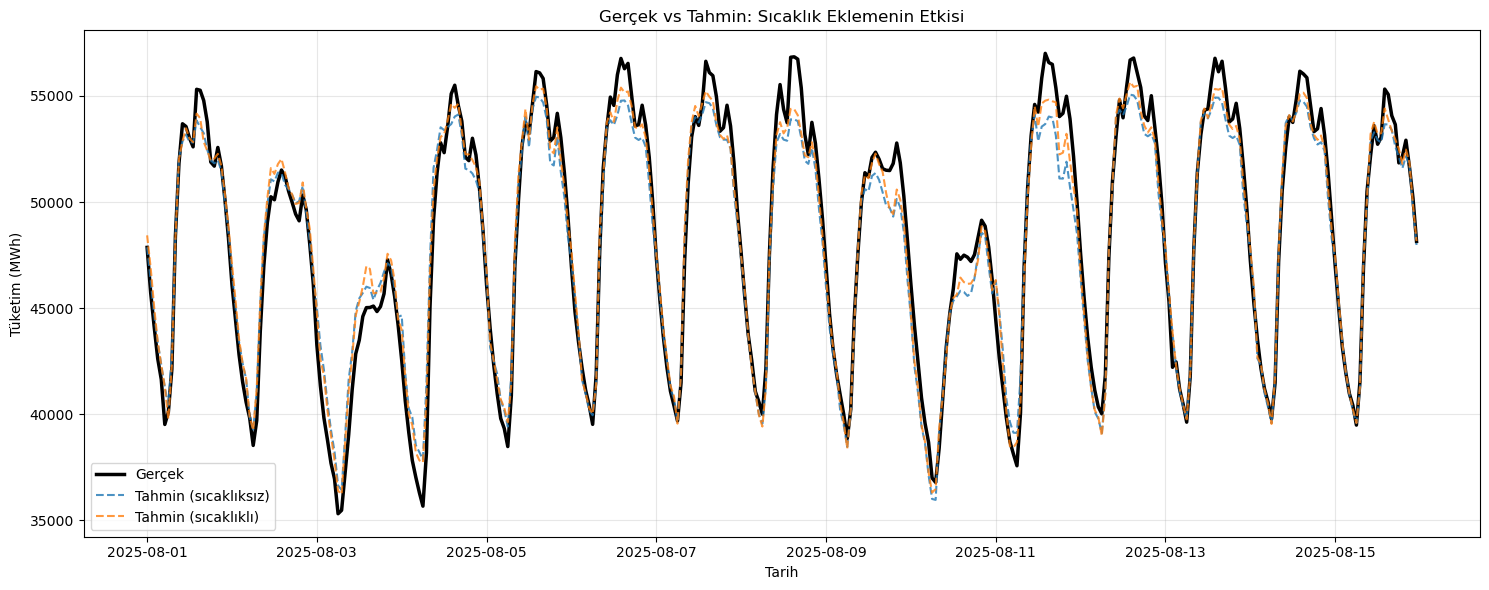

In [54]:
# Yeni tahminleri seriye çevir
tahmin_yeni_serisi = pd.Series(y_pred_yeni, index=y_test_yeni.index)

# Aynı 2 haftalık kesit
baslangic = "2025-08-01"
bitis = "2025-08-15"

plt.figure(figsize=(15, 6))
plt.plot(y_test.loc[baslangic:bitis].index, y_test.loc[baslangic:bitis].values, 
         label="Gerçek", linewidth=2.5, color="black")
plt.plot(tahmin_serisi.loc[baslangic:bitis].index, tahmin_serisi.loc[baslangic:bitis].values, 
         label="Tahmin (sıcaklıksız)", linewidth=1.5, linestyle="--", alpha=0.8)
plt.plot(tahmin_yeni_serisi.loc[baslangic:bitis].index, tahmin_yeni_serisi.loc[baslangic:bitis].values, 
         label="Tahmin (sıcaklıklı)", linewidth=1.5, linestyle="--", alpha=0.8)
plt.title("Gerçek vs Tahmin: Sıcaklık Eklemenin Etkisi")
plt.xlabel("Tarih")
plt.ylabel("Tüketim (MWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

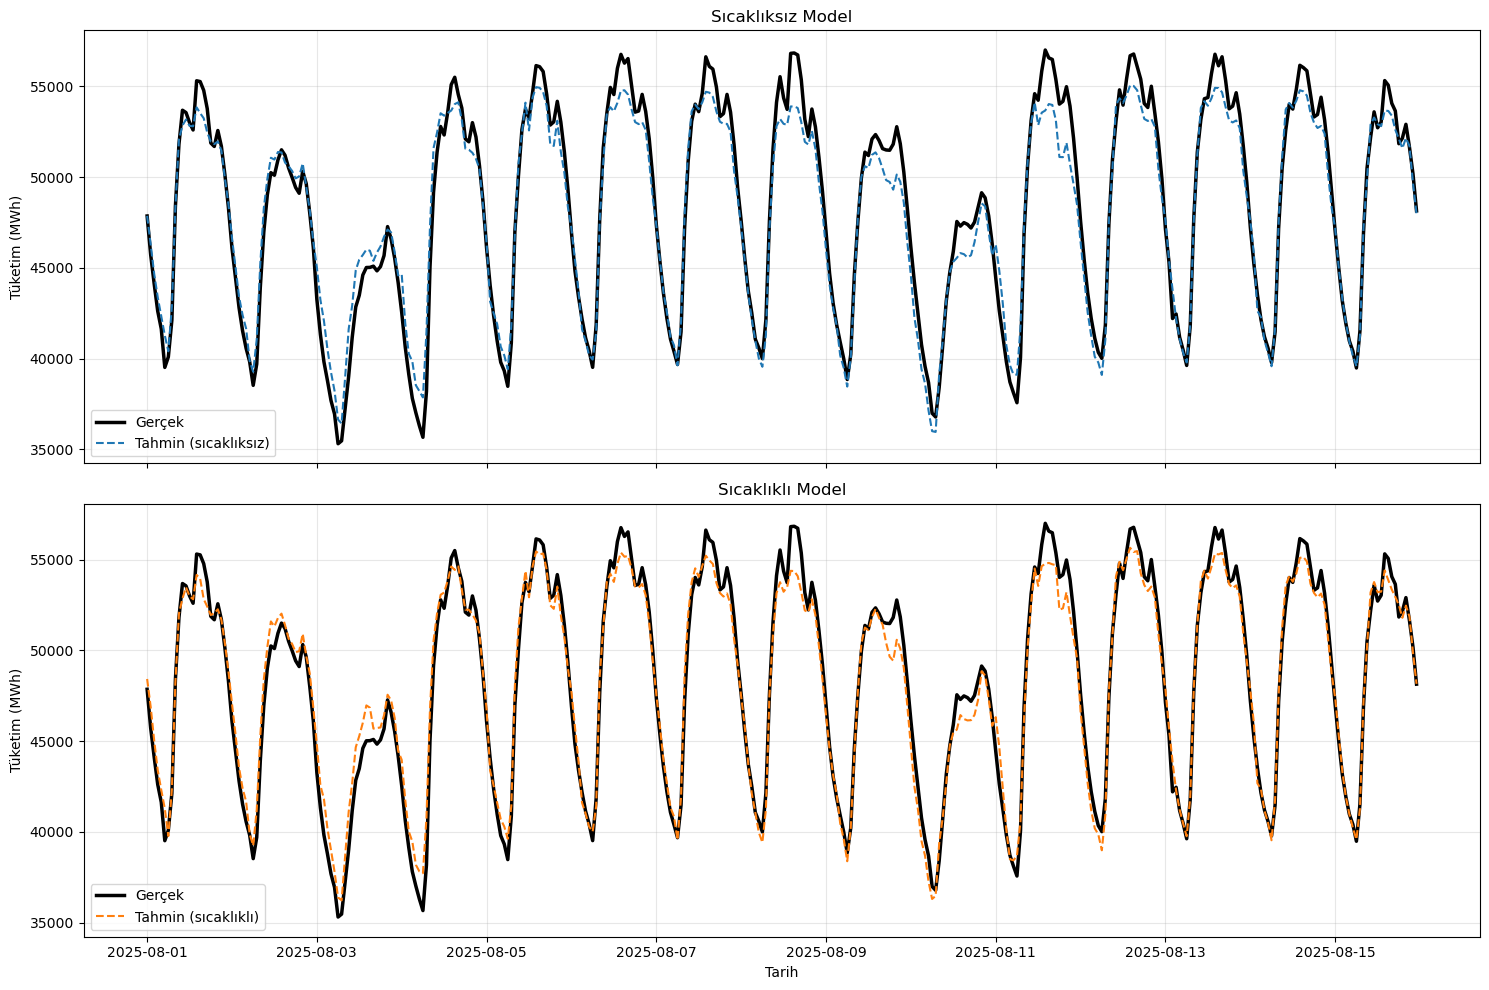

In [55]:
baslangic = "2025-08-01"
bitis = "2025-08-15"

# İki grafik, alt alta (2 satır, 1 sütun), aynı x eksenini paylaşsınlar
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# ÜST GRAFİK: Gerçek vs Sıcaklıksız
ax1.plot(y_test.loc[baslangic:bitis].index, y_test.loc[baslangic:bitis].values,
         label="Gerçek", linewidth=2.5, color="black")
ax1.plot(tahmin_serisi.loc[baslangic:bitis].index, tahmin_serisi.loc[baslangic:bitis].values,
         label="Tahmin (sıcaklıksız)", linewidth=1.5, linestyle="--", color="tab:blue")
ax1.set_title("Sıcaklıksız Model")
ax1.set_ylabel("Tüketim (MWh)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ALT GRAFİK: Gerçek vs Sıcaklıklı
ax2.plot(y_test.loc[baslangic:bitis].index, y_test.loc[baslangic:bitis].values,
         label="Gerçek", linewidth=2.5, color="black")
ax2.plot(tahmin_yeni_serisi.loc[baslangic:bitis].index, tahmin_yeni_serisi.loc[baslangic:bitis].values,
         label="Tahmin (sıcaklıklı)", linewidth=1.5, linestyle="--", color="tab:orange")
ax2.set_title("Sıcaklıklı Model")
ax2.set_xlabel("Tarih")
ax2.set_ylabel("Tüketim (MWh)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

İlk modelim tepe tüketimleri eksik tahmin ediyordu. Analiz ettim, sıcaklık-tüketim ilişkisinin U şeklinde olduğunu ve modelin sıcaklık bilgisi olmadan klima kaynaklı pikleri yakalayamadığını gördüm. Open-Meteo'dan üç büyük şehrin sıcaklık verisini çekip ekledim ve RMSE'yi %8 iyileştirdim, özellikle tepe noktalarında.

In [56]:
# Farklı ayarları deneyelim ve karşılaştıralım
ayarlar = [
    {"n_estimators": 500,  "learning_rate": 0.05},   # mevcut model
    {"n_estimators": 1000, "learning_rate": 0.05},   # daha çok ağaç
    {"n_estimators": 1000, "learning_rate": 0.02},   # daha çok ağaç + daha yavaş
    {"n_estimators": 2000, "learning_rate": 0.01},   # en çok ağaç + en yavaş
]

print(f"{'Ayar':<32}{'Train MAPE':<14}{'Test MAPE':<14}")
print("=" * 60)

for ayar in ayarlar:
    m = lgb.LGBMRegressor(**ayar, random_state=42, verbose=-1)
    m.fit(X_train_yeni, y_train_yeni)
    
    # Hem train hem test tahmini
    pred_train = m.predict(X_train_yeni)
    pred_test = m.predict(X_test_yeni)
    
    # MAPE hesapla
    mape_tr = np.mean(np.abs((y_train_yeni - pred_train) / y_train_yeni)) * 100
    mape_te = np.mean(np.abs((y_test_yeni - pred_test) / y_test_yeni)) * 100
    
    etiket = f"n={ayar['n_estimators']}, lr={ayar['learning_rate']}"
    print(f"{etiket:<32}{mape_tr:<14.3f}{mape_te:<14.3f}")

Ayar                            Train MAPE    Test MAPE     
n=500, lr=0.05                  1.316         1.733         
n=1000, lr=0.05                 1.082         1.657         
n=1000, lr=0.02                 1.377         1.779         
n=2000, lr=0.01                 1.380         1.767         


In [57]:
# Kazanan ayarla modeli güncelle
model_final = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)
model_final.fit(X_train_yeni, y_train_yeni)

# Final tahminler
y_pred_final = model_final.predict(X_test_yeni)

# Final metrikler
mae_f = mean_absolute_error(y_test_yeni, y_pred_final)
rmse_f = np.sqrt(mean_squared_error(y_test_yeni, y_pred_final))
mape_f = np.mean(np.abs((y_test_yeni - y_pred_final) / y_test_yeni)) * 100
r2_f = r2_score(y_test_yeni, y_pred_final)

print("=== FINAL MODEL (n=1000, lr=0.05, sıcaklıklı) ===")
print(f"MAE : {mae_f:,.0f} MWh")
print(f"RMSE: {rmse_f:,.0f} MWh")
print(f"MAPE: {mape_f:.2f}%")
print(f"R²  : {r2_f:.4f}")

=== FINAL MODEL (n=1000, lr=0.05, sıcaklıklı) ===
MAE : 667 MWh
RMSE: 995 MWh
MAPE: 1.66%
R²  : 0.9771


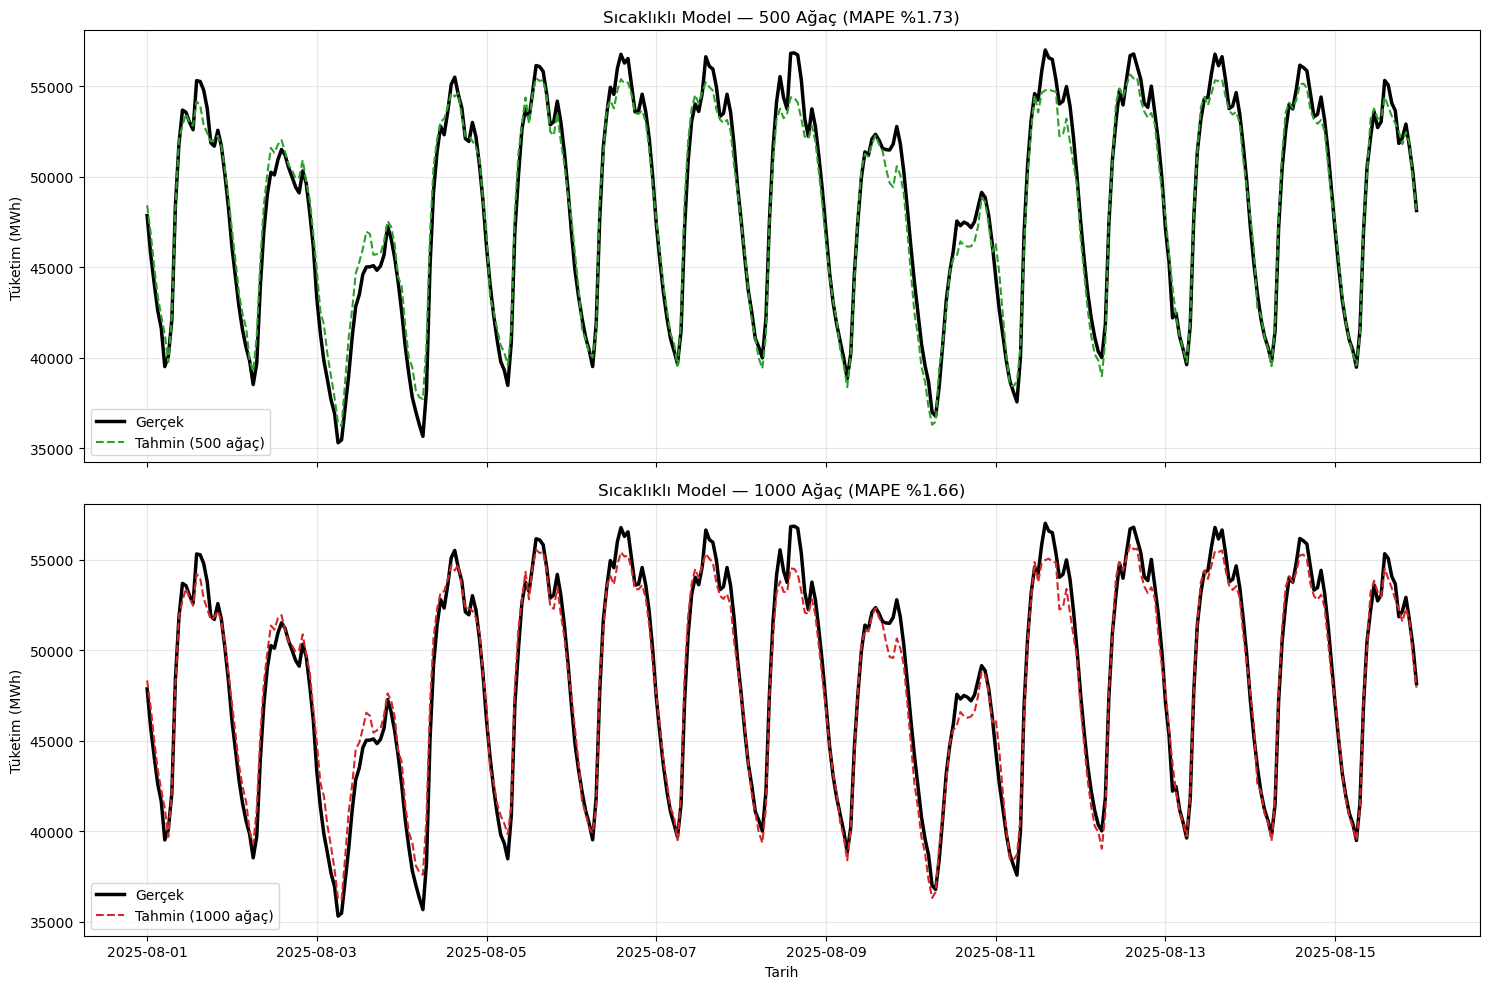

In [58]:
baslangic = "2025-08-01"
bitis = "2025-08-15"

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# ÜST: Gerçek vs Sıcaklıklı 500 ağaç
ax1.plot(y_test.loc[baslangic:bitis].index, y_test.loc[baslangic:bitis].values,
         label="Gerçek", linewidth=2.5, color="black")
ax1.plot(tahmin_yeni_serisi.loc[baslangic:bitis].index, tahmin_yeni_serisi.loc[baslangic:bitis].values,
         label="Tahmin (500 ağaç)", linewidth=1.5, linestyle="--", color="tab:green")
ax1.set_title("Sıcaklıklı Model — 500 Ağaç (MAPE %1.73)")
ax1.set_ylabel("Tüketim (MWh)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ALT: Gerçek vs Sıcaklıklı 1000 ağaç (final)
tahmin_final_serisi = pd.Series(y_pred_final, index=y_test_yeni.index)
ax2.plot(y_test.loc[baslangic:bitis].index, y_test.loc[baslangic:bitis].values,
         label="Gerçek", linewidth=2.5, color="black")
ax2.plot(tahmin_final_serisi.loc[baslangic:bitis].index, tahmin_final_serisi.loc[baslangic:bitis].values,
         label="Tahmin (1000 ağaç)", linewidth=1.5, linestyle="--", color="tab:red")
ax2.set_title("Sıcaklıklı Model — 1000 Ağaç (MAPE %1.66)")
ax2.set_xlabel("Tarih")
ax2.set_ylabel("Tüketim (MWh)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()